<div style="background:#1a73e8;padding:20px;border-radius:10px;margin-bottom:10px">
<h1 style="color:white;text-align:center">📊 01 — Analyse Exploratoire des Données (EDA)</h1>
<p style="color:white;font-size:15px;text-align:center">
Projet : Prédiction du State of Health (SoH) des batteries Li-ion<br>
Objectif : Comprendre la structure, identifier les variables clés, détecter les anomalies
</p></div>

## 🏭 Contexte industriel
Les batteries Li-ion sont au cœur des systèmes modernes : **véhicules électriques**, **stockage stationnaire**, **IoT et lampadaires solaires**.  
Le **SoH** (State of Health) est un indicateur clé permettant d'anticiper les pannes, optimiser la maintenance et réduire les coûts.

**Question centrale :** Peut-on estimer le SoH à partir des mesures de tension, courant, température et SoC observées sur une portion de cycle de décharge ?

## 📦 Étape 1 — Chargement et aperçu des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# Chargement du dataset
df = pd.read_csv('data/battery_health_dataset.csv')

print("=" * 50)
print("   APERÇU GÉNÉRAL DU DATASET")
print("=" * 50)
print(f"  Dimensions       : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"  Batteries        : {df['battery_id'].nunique()} batteries distinctes")
print(f"  Cycles uniques   : {df.groupby(['battery_id','cycle_number']).ngroups:,}")
print(f"  Valeurs manquantes : {df.isnull().sum().sum()}")
print(f"  Types de données :")
print(df.dtypes.to_string(dtype=False))
print()
print("Aperçu des premières lignes :")
df.head(8)

   APERÇU GÉNÉRAL DU DATASET
  Dimensions       : 29,180 lignes × 7 colonnes
  Batteries        : 24 batteries distinctes
  Cycles uniques   : 1,459
  Valeurs manquantes : 0
  Types de données :
Voltage_measured        float64
Current_measured        float64
Temperature_measured    float64
SoC                     float64
cycle_number              int64
battery_id               object
SoH                     float64

Aperçu des premières lignes :


,Voltage_measured,Current_measured,Temperature_measured,SoC,cycle_number,battery_id,SoH
0,3.964430,-0.912319,5.678270,97.699721,1,B0047,83.626322
1,3.843126,-0.995334,6.408629,92.510061,1,B0047,83.626322
2,3.796380,-0.995601,7.576325,87.422980,1,B0047,83.626322
3,3.749510,-0.995187,8.334522,82.444342,1,B0047,83.626322
4,3.699625,-0.995266,7.389032,77.465757,1,B0047,83.626322
5,3.646471,-0.995535,7.006770,72.486440,1,B0047,83.626322
6,3.612912,-0.995449,7.581404,67.504608,1,B0047,83.626322
7,3.585191,-0.994852,8.098570,62.523773,1,B0047,83.626322


In [2]:
# Statistiques descriptives complètes
print("Statistiques descriptives :")
df.describe().round(3)

Statistiques descriptives :


,Voltage_measured,Current_measured,Temperature_measured,SoC,cycle_number,SoH
count,29180.000,29180.000,29180.000,29180.000,29180.000,29180.000
mean,3.457,-2.327,34.949,49.576,53.570,82.348
std,0.260,0.977,10.819,29.087,45.553,7.041
min,2.731,-4.031,4.723,1.539,1.000,70.022
25%,3.315,-2.015,29.591,23.349,18.000,76.145
50%,3.470,-2.008,33.323,48.581,37.000,82.930
75%,3.630,-1.989,40.177,73.983,84.000,88.174
max,4.231,-0.890,66.672,98.757,197.000,122.012


## 📊 Étape 2 — Structure des cycles par batterie

Cycles par batterie :
battery_id
B0047     11
B0048     14
B0046     17
B0026     27
B0025     28
B0028     28
B0027     28
B0039     33
B0040     33
B0038     35
B0029     40
B0030     40
B0032     40
B0031     40
B0044     50
B0043     54
B0042     57
B0034     70
B0018    104
B0006    109
B0033    115
B0005    123
B0007    167
B0036    196

Bins par cycle — min: 20 | max: 20 | médiane: 20


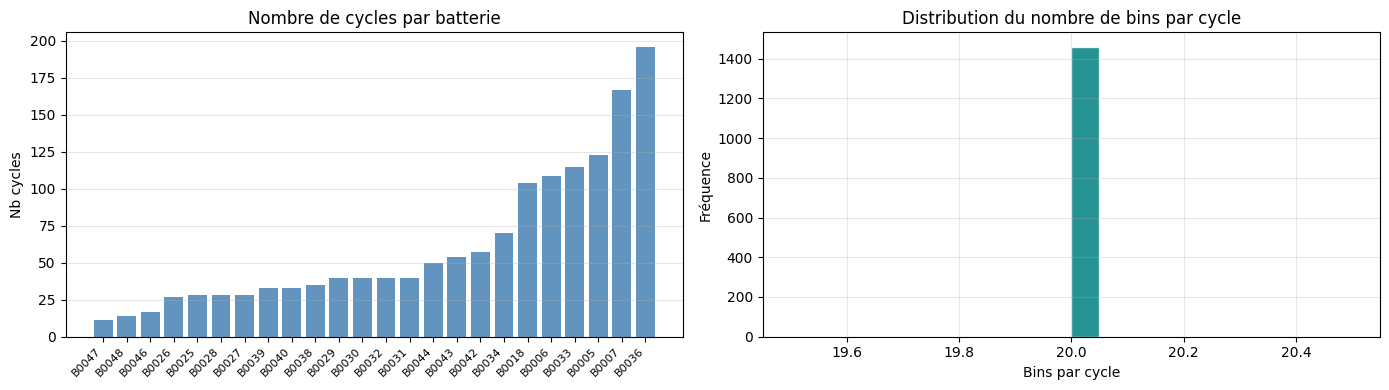

✅ Figure sauvegardée


In [3]:
# Nombre de cycles par batterie et bins par cycle
cycles_per_bat = df.groupby('battery_id')['cycle_number'].nunique().sort_values()
bins_per_cycle = df.groupby(['battery_id','cycle_number']).size()

print("Cycles par batterie :")
print(cycles_per_bat.to_string())
print(f"\nBins par cycle — min: {bins_per_cycle.min()} | max: {bins_per_cycle.max()} | médiane: {bins_per_cycle.median():.0f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Cycles par batterie
axes[0].bar(range(len(cycles_per_bat)), cycles_per_bat.values, color='steelblue', alpha=0.85)
axes[0].set_xticks(range(len(cycles_per_bat)))
axes[0].set_xticklabels(cycles_per_bat.index, rotation=45, ha='right', fontsize=8)
axes[0].set_title("Nombre de cycles par batterie")
axes[0].set_ylabel("Nb cycles")
axes[0].grid(axis='y', alpha=0.3)

# Distribution des bins par cycle
axes[1].hist(bins_per_cycle.values, bins=20, color='teal', alpha=0.85, edgecolor='white')
axes[1].set_title("Distribution du nombre de bins par cycle")
axes[1].set_xlabel("Bins par cycle")
axes[1].set_ylabel("Fréquence")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/fig_cycles_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"✅ Figure sauvegardée")

## 📈 Étape 3 — Évolution du SoH par batterie

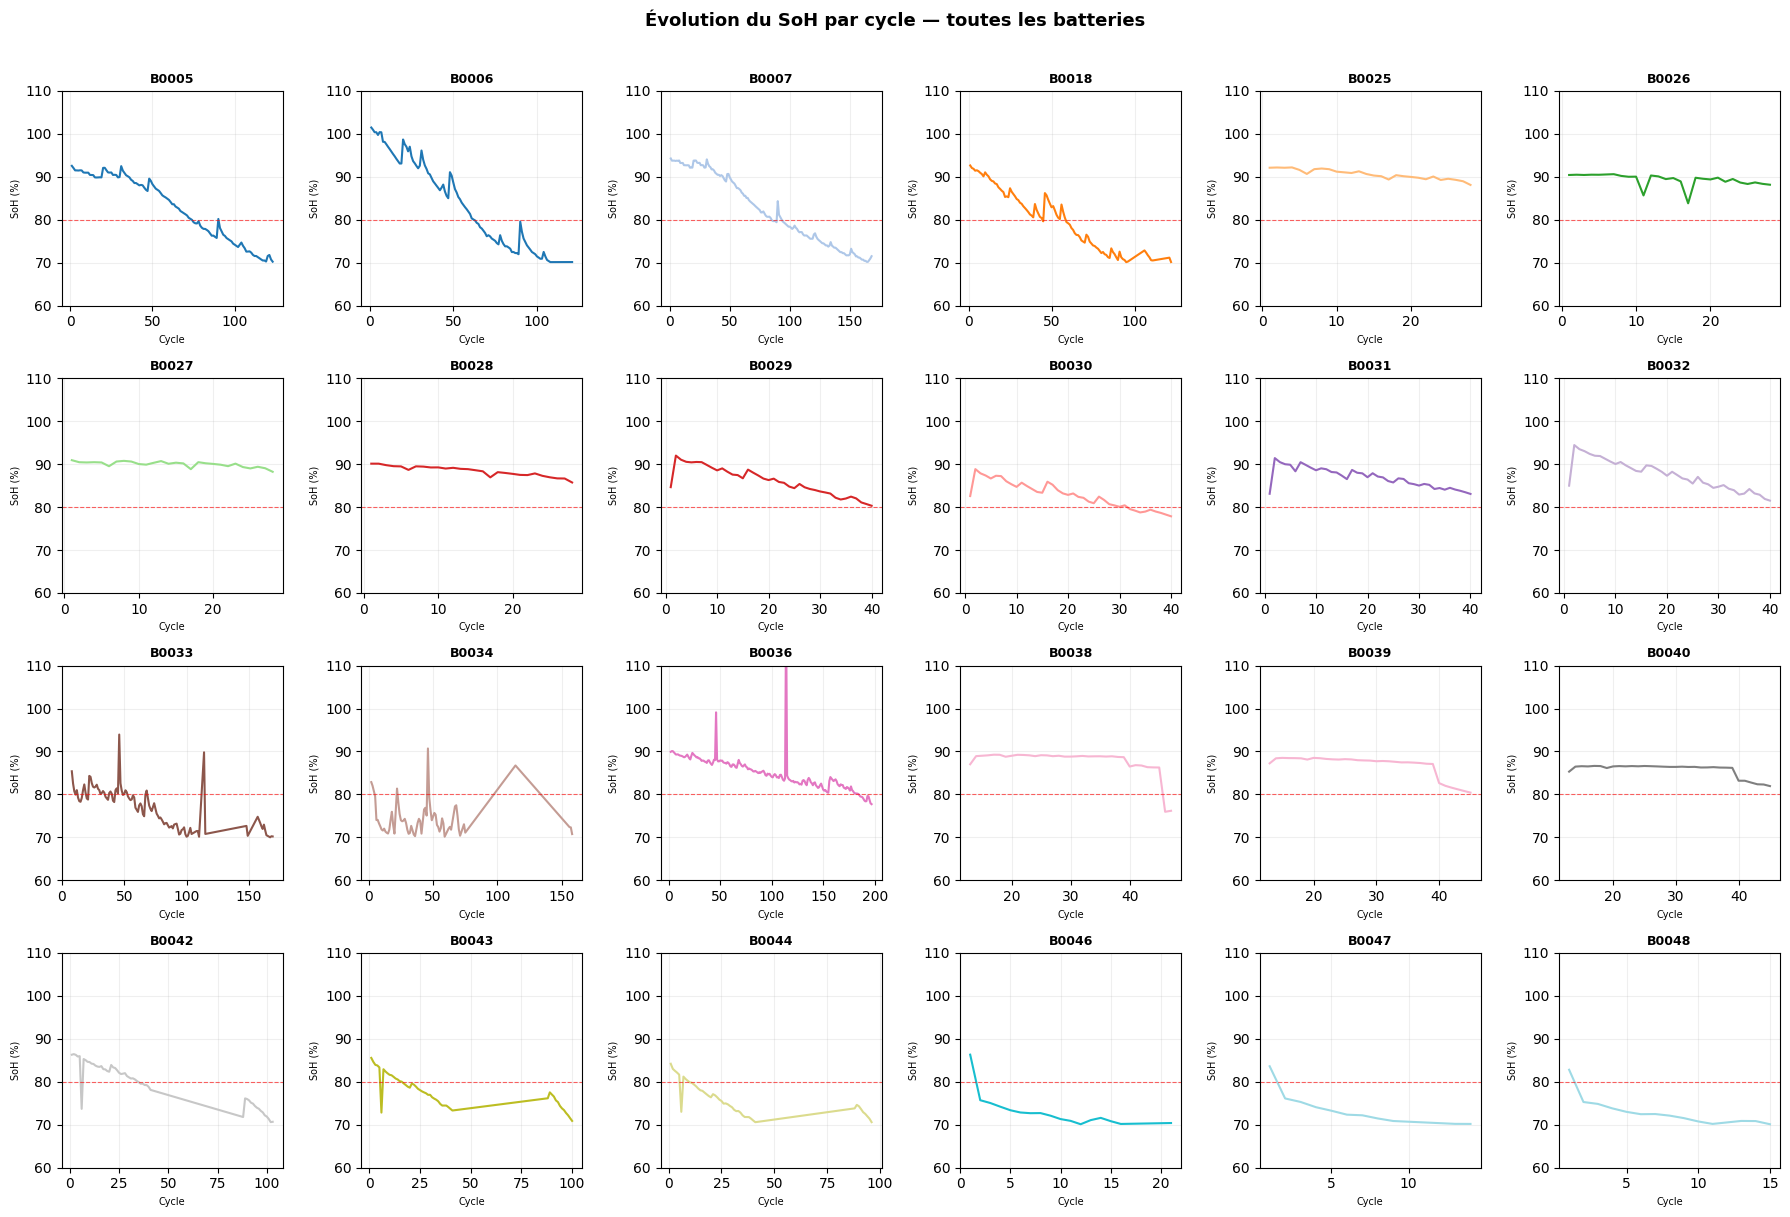

✅ Figure sauvegardée

Plage globale du SoH : 70.02% → 122.01%


In [4]:
# SoH moyen par cycle pour chaque batterie
soh_by_cycle = df.groupby(['battery_id','cycle_number'])['SoH'].first().reset_index()

batteries = sorted(df['battery_id'].unique())
n = len(batteries)
cols = 6
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 3))
axes = axes.flatten()

colors = plt.cm.tab20(np.linspace(0, 1, n))

for i, bat in enumerate(batteries):
    sub = soh_by_cycle[soh_by_cycle['battery_id'] == bat]
    axes[i].plot(sub['cycle_number'], sub['SoH'], color=colors[i], lw=1.5)
    axes[i].axhline(80, color='red', ls='--', lw=0.8, alpha=0.6)
    axes[i].set_title(bat, fontsize=9, fontweight='bold')
    axes[i].set_xlabel("Cycle", fontsize=7)
    axes[i].set_ylabel("SoH (%)", fontsize=7)
    axes[i].grid(alpha=0.2)
    axes[i].set_ylim(60, 110)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Évolution du SoH par cycle — toutes les batteries", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/fig_soh_evolution.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée")
print(f"\nPlage globale du SoH : {df['SoH'].min():.2f}% → {df['SoH'].max():.2f}%")

## ⚠️ Étape 4 — Détection des anomalies

In [5]:
# Détection des anomalies dans le SoH
print("=== DÉTECTION D'ANOMALIES ===")

# Anomalie 1 : SoH > 100%
soh_over_100 = df[df['SoH'] > 100]
print(f"SoH > 100% : {len(soh_over_100)} lignes ({len(soh_over_100)/len(df)*100:.2f}%)")
if len(soh_over_100) > 0:
    print("  Batteries concernées :", soh_over_100['battery_id'].unique())

# Anomalie 2 : SoH < 50% (suspicieux pour nos batteries)
soh_under_50 = df[df['SoH'] < 50]
print(f"SoH < 50% : {len(soh_under_50)} lignes")

# Anomalie 3 : Variations brutales du SoH entre cycles consécutifs
soh_cycle = df.groupby(['battery_id','cycle_number'])['SoH'].first().reset_index()
soh_cycle['soh_diff'] = soh_cycle.groupby('battery_id')['SoH'].diff().abs()
brutal_changes = soh_cycle[soh_cycle['soh_diff'] > 10]
print(f"Variations brusques SoH > 10% entre cycles : {len(brutal_changes)} cas")
if len(brutal_changes) > 0:
    print(brutal_changes[['battery_id','cycle_number','SoH','soh_diff']].head(8).to_string())

# Anomalie 4 : Tension hors plage physique [2.5V, 4.5V]
volt_out = df[(df['Voltage_measured'] < 2.5) | (df['Voltage_measured'] > 4.5)]
print(f"\nTension hors [2.5V, 4.5V] : {len(volt_out)} lignes")

# Anomalie 5 : Température négative ou > 60°C
temp_out = df[(df['Temperature_measured'] < 0) | (df['Temperature_measured'] > 60)]
print(f"Température hors [0°C, 60°C] : {len(temp_out)} lignes")

print("\n✅ Analyse des anomalies terminée")

=== DÉTECTION D'ANOMALIES ===
SoH > 100% : 140 lignes (0.48%)
  Batteries concernées : ['B0036' 'B0006']
SoH < 50% : 0 lignes
Variations brusques SoH > 10% entre cycles : 19 cas
    battery_id  cycle_number        SoH   soh_diff
812      B0033            46  93.944057  13.675724
813      B0033            47  82.612833  11.331224
874      B0033           114  89.810815  19.662011
875      B0033           115  70.800637  19.010178
908      B0034            22  81.366371  10.480574
930      B0034            46  90.705033  15.618745
931      B0034            47  79.366460  11.338573
955      B0034           114  86.747353  15.639994

Tension hors [2.5V, 4.5V] : 0 lignes
Température hors [0°C, 60°C] : 160 lignes

✅ Analyse des anomalies terminée


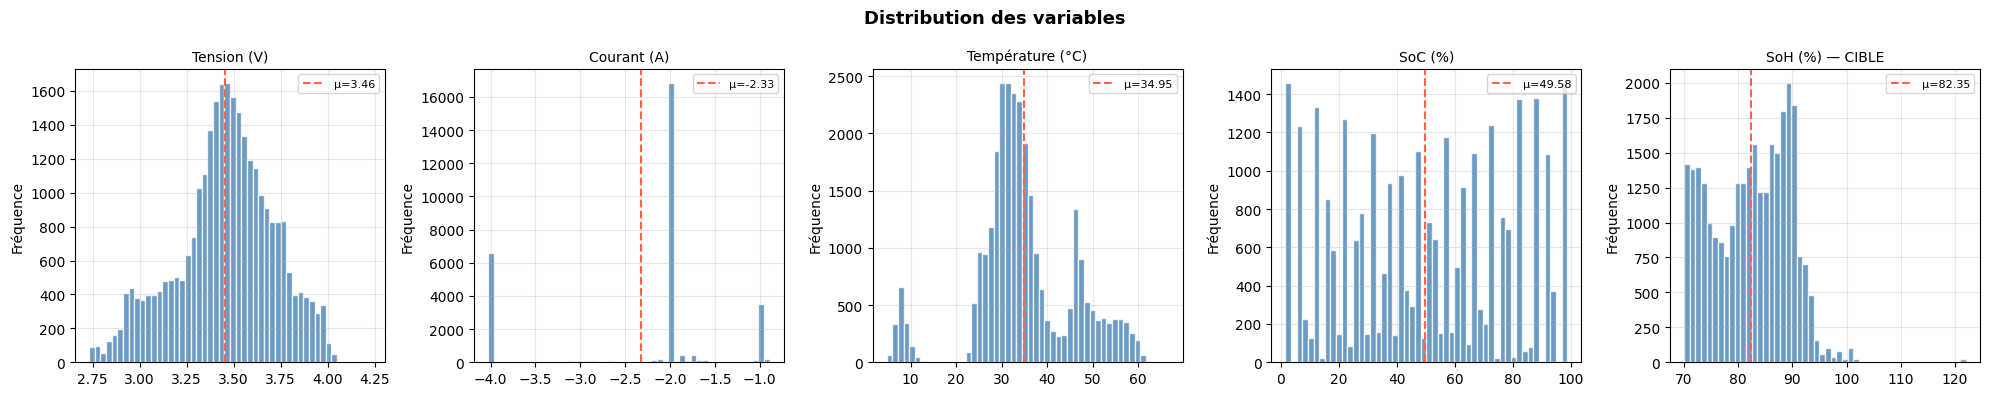

In [6]:
# Visualisation des distributions de chaque variable (avec marquage des outliers)
features_viz = ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'SoC', 'SoH']
labels_viz   = ['Tension (V)', 'Courant (A)', 'Température (°C)', 'SoC (%)', 'SoH (%) — CIBLE']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, feat, lbl in zip(axes, features_viz, labels_viz):
    ax.hist(df[feat], bins=50, color='steelblue', alpha=0.8, edgecolor='white')
    ax.set_title(lbl, fontsize=10)
    ax.set_ylabel("Fréquence")
    mu = df[feat].mean()
    ax.axvline(mu, color='tomato', ls='--', lw=1.5, label=f'μ={mu:.2f}')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Distribution des variables", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

## 🔗 Étape 5 — Matrice de corrélation

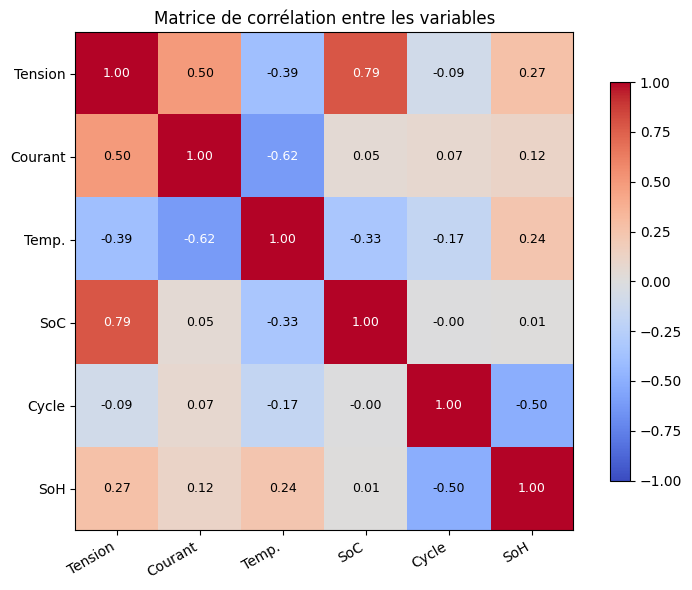

📊 Corrélations avec le SoH :
  cycle_number           -0.5049  ██████████
  SoC                    +0.0051  
  Current_measured       +0.1171  ██
  Temperature_measured   +0.2416  ████
  Voltage_measured       +0.2661  █████

🔍 Observation critique :
  cycle_number corrèle fortement avec SoH (-0.50) → le LSTM risque
  d'apprendre 'cycle élevé = SoH bas' plutôt que la physique électrochimique.
  On inclura cycle_number comme demandé par l'énoncé, mais on restera
  vigilant lors de l'interprétation des performances.

  SoC corrèle très peu avec SoH (≈0.005) : le SoC varie DANS chaque cycle
  (de 100% à ~0%) alors que le SoH est une propriété INTER-cycles.
  La corrélation brute est donc trompeuse — la valeur de SoC au sein
  d'une séquence glissante contient bien de l'information sur la dégradation.


In [7]:
# Corrélation entre les variables
features_corr = ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'SoC', 'cycle_number', 'SoH']
labels_corr   = ['Tension', 'Courant', 'Temp.', 'SoC', 'Cycle', 'SoH']
corr = df[features_corr].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(6)); ax.set_xticklabels(labels_corr, rotation=30, ha='right')
ax.set_yticks(range(6)); ax.set_yticklabels(labels_corr)
for i in range(6):
    for j in range(6):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha='center', va='center', fontsize=9,
                color='white' if abs(v) > 0.6 else 'black')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.title("Matrice de corrélation entre les variables")
plt.tight_layout()
plt.savefig('figures/fig_correlation.png', dpi=100, bbox_inches='tight')
plt.show()

print("📊 Corrélations avec le SoH :")
corr_soh = corr['SoH'].drop('SoH').sort_values()
for feat, val in corr_soh.items():
    bar = "█" * int(abs(val) * 20)
    sign = "+" if val > 0 else "-"
    print(f"  {feat:<22} {sign}{abs(val):.4f}  {bar}")

print()
print("🔍 Observation critique :")
print("  cycle_number corrèle fortement avec SoH (-0.50) → le LSTM risque")
print("  d'apprendre 'cycle élevé = SoH bas' plutôt que la physique électrochimique.")
print("  On inclura cycle_number comme demandé par l'énoncé, mais on restera")
print("  vigilant lors de l'interprétation des performances.")
print()
print("  SoC corrèle très peu avec SoH (≈0.005) : le SoC varie DANS chaque cycle")
print("  (de 100% à ~0%) alors que le SoH est une propriété INTER-cycles.")
print("  La corrélation brute est donc trompeuse — la valeur de SoC au sein")
print("  d'une séquence glissante contient bien de l'information sur la dégradation.")

## 💡 Étape 6 — Réponses aux 5 questions de réflexion de l'énoncé

> Ces réponses font partie intégrante du projet et montrent la compréhension conceptuelle du problème.

In [8]:
from IPython.display import display, HTML

questions = {
    1: ("Pourquoi le SoC est-il une variable clé pour estimer le SoH ?",
        """Le SoC (State of Charge) représente le niveau de charge instantané de la batterie.
    Il est clé pour estimer le SoH car :
    - La courbe SoC vs Tension (courbe OCV) se dégrade progressivement avec le vieillissement.
      Une batterie âgée présente une tension plus basse pour le même SoC.
    - La vitesse à laquelle le SoC diminue sous courant constant est un indicateur
      de la résistance interne et donc de la dégradation.
    - Dans une fenêtre glissante, la séquence SoC(t), SoC(t+1)... capture la dynamique
      de décharge, dont le profil change avec le SoH.
    Note : la corrélation brute SoC-SoH est quasi nulle (0.005) car SoC varie DANS chaque
    cycle indépendamment du SoH. C'est la DYNAMIQUE de la séquence de SoC qui porte
    l'information, pas la valeur absolue."""),

    2: ("Quel intérêt de découper un cycle en plusieurs fenêtres ?",
        """Plusieurs bénéfices :
    1. Augmentation du nombre d'échantillons : 1 cycle → (bins - WINDOW + 1) fenêtres,
       ce qui multiplie les données d'entraînement.
    2. Capture de patterns locaux : différentes portions du cycle (début, milieu, fin
       de décharge) portent des informations distinctes sur l'état de la batterie.
    3. Robustesse : même si une partie du cycle est manquante ou bruitée, d'autres
       fenêtres du même cycle restent exploitables.
    4. Prédiction partielle : en production, on peut prédire le SoH à partir d'une
       portion de cycle seulement (sans attendre la fin complète)."""),

    3: ("Que se passerait-il si la fenêtre était trop courte ou trop longue ?",
        """→ Fenêtre TROP COURTE (ex: 2-3 bins) :
    - Pas assez de contexte temporel pour le LSTM : il ne voit qu'un flash du signal.
    - Risque de sur-apprentissage sur du bruit local.
    - Perte de la dynamique de décharge (comment évolue la tension ?).

    → Fenêtre TROP LONGUE (ex: 18-20 bins = tout le cycle) :
    - Plus d'augmentation des données (1 seule fenêtre par cycle).
    - Le LSTM doit mémoriser trop d'information sur une longue séquence.
    - Si les cycles ont des longueurs variables, les fenêtres longues posent
      des problèmes de padding.

    → Compromis optimal : 30-50% de la longueur du cycle.
    Pour 20 bins par cycle, WINDOW=10 est un bon équilibre."""),

    4: ("Quels risques de biais si les cycles sont mal répartis train/test ?",
        """Risques principaux :
    1. DATA LEAKAGE par fenêtre : si on mélange les fenêtres sans respecter les batteries,
       le modèle voit des fenêtres de la MÊME batterie en train ET test → performances
       artificiellement gonflées (le modèle mémorise la batterie).
    2. BIAIS DE SÉLECTION : si le test ne contient que des batteries avec peu de cycles
       (SoH élevé) ou beaucoup de cycles (SoH bas), les métriques ne reflètent pas
       la performance réelle sur l'ensemble de la plage de SoH.
    3. CORRÉLATION TEMPORELLE : des fenêtres consécutives d'un même cycle sont très
       similaires → si elles se retrouvent en train et test, les métriques sont trompeuses.

    → Solution : split par BATTERIE ENTIÈRE, en s'assurant que toutes les plages
      de SoH sont représentées dans train ET test."""),

    5: ("Dans quels cas industriels ce type de modèle est pertinent ?",
        """Applications industrielles directes :
    1. Véhicules électriques : prédire l'autonomie restante et planifier la maintenance.
    2. Stockage stationnaire (panneaux solaires, éoliennes) : détecter les batteries
       défaillantes avant qu'elles ne causent une panne système.
    3. IoT et lampadaires solaires (contexte de l'énoncé) : maintenance préventive
       à distance, réduction des coûts d'intervention terrain.
    4. Industrie aéronautique et marine : sécurité critique, tolérance zéro aux pannes.
    5. Data centers : systèmes UPS (onduleurs), garantir la disponibilité.

    Le modèle LSTM est particulièrement pertinent quand :
    - Les données de cycle sont disponibles en continu (capteurs embarqués).
    - On veut une prédiction en temps réel (inférence rapide sur une fenêtre).
    - Le comportement de dégradation est progressif et non-linéaire."""),
}

# ── display(HTML) contourne la troncature Jupyter ──
html = ""
for num, (question, reponse) in questions.items():
    reponse_html = reponse.replace('\n', '<br>').replace('    ', '&nbsp;&nbsp;&nbsp;&nbsp;')
    html += f"""
    <div style="border:1px solid #444; border-radius:8px; margin:12px 0; overflow:hidden;">
        <div style="background:#1a73e8; padding:10px 14px;">
            <span style="color:white; font-weight:bold; font-size:14px;">
                Q{num}. {question}
            </span>
        </div>
        <div style="padding:12px 16px; font-family:monospace; font-size:13px;
                    background:#1e1e1e; color:#d4d4d4; line-height:1.8;">
            {reponse_html}
        </div>
    </div>
    """

html += """<div style="color:#4caf50; font-weight:bold; margin-top:12px; font-size:14px;">
    ✅ Les 5 questions de réflexion de l'énoncé ont été traitées</div>"""

display(HTML(html))
